# Titanic Survival Prediction
## Machine Learning Classification Project
### Task 01 - TITANIC CLASSIFICATION

**Objective:**  
Predict whether a passenger survived the Titanic disaster using features like age, gender, class, and family size.


# STEP 1: LOAD THE DATASET

1.1 Import All Libraries


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

1.2 Load Data Using Seaborn

In [ ]:
# Load Titanic dataset directly from seaborn (no CSV download needed)
df = sns.load_dataset('titanic')

print("Dataset loaded!")
print(f"Shape: {df.shape}")  # (891, 15)
print(f"Columns: {list(df.columns)}")

Dataset loaded!
Shape: (891, 15)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


1.3 Basic Overview

In [ ]:
print("=== DATASET OVERVIEW ===")
print("\n1.3.1 Shape:", df.shape)
print("\n1.3.2 Info:")
print(df.info())
print("\n1.3.3 First 5 rows:")
print(df.head())
print("\n1.3.4 Statistical Summary:")
print(df.describe())

=== DATASET OVERVIEW ===

1.3.1 Shape: (891, 15)

1.3.2 Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

1.3.3 First 5 rows:
   sur

1.4 Target Variable (Survived) Distribution

In [ ]:
print("\n1.4.1 Value counts:")
print(df['survived'].value_counts())

print("\n1.4.2 Survival rate:")
survival_rate = df['survived'].mean()
print(f"Did not survive: {(1-survival_rate):.2%}")
print(f"Survived: {survival_rate:.2%}")


1.4.1 Value counts:
survived
0    549
1    342
Name: count, dtype: int64

1.4.2 Survival rate:
Did not survive: 61.62%
Survived: 38.38%


# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

2.1 Survival Rate by Sex

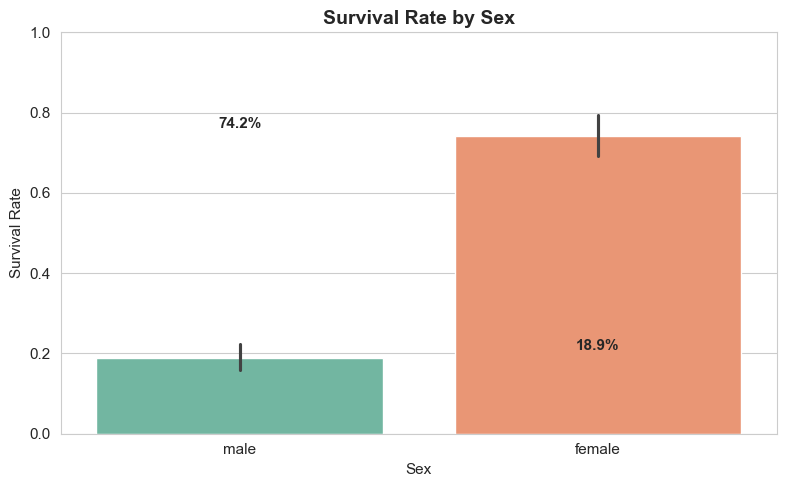

Survival by sex:
sex
female    0.7420
male      0.1889
Name: survived, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='sex', y='survived', data=df, palette='Set2')
plt.title('Survival Rate by Sex', fontsize=14, fontweight='bold')
plt.ylabel('Survival Rate')
plt.xlabel('Sex')

# Add percentage labels on bars
for i, sex in enumerate(['female', 'male']):
    rate = df[df['sex'] == sex]['survived'].mean()
    plt.text(i, rate + 0.02, f'{rate:.1%}', ha='center', fontweight='bold')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Print exact numbers
print("Survival by sex:")
print(df.groupby('sex')['survived'].mean().round(4))

2.2 Survival Rate by Passenger Class

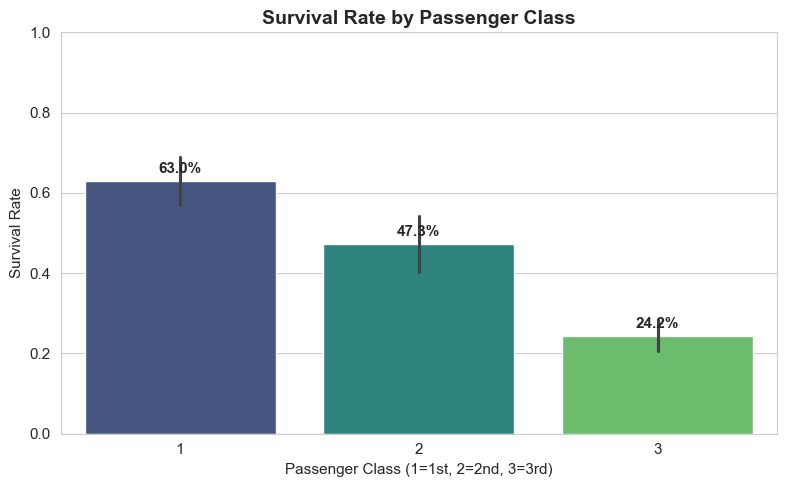

Survival by class:
pclass
1    0.6296
2    0.4728
3    0.2424
Name: survived, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x='pclass', y='survived', data=df, palette='viridis')
plt.title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class (1=1st, 2=2nd, 3=3rd)')

for i, pclass in enumerate([1, 2, 3]):
    rate = df[df['pclass'] == pclass]['survived'].mean()
    plt.text(i, rate + 0.02, f'{rate:.1%}', ha='center', fontweight='bold')

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Survival by class:")
print(df.groupby('pclass')['survived'].mean().round(4))

2.3 Age Distribution by Survival

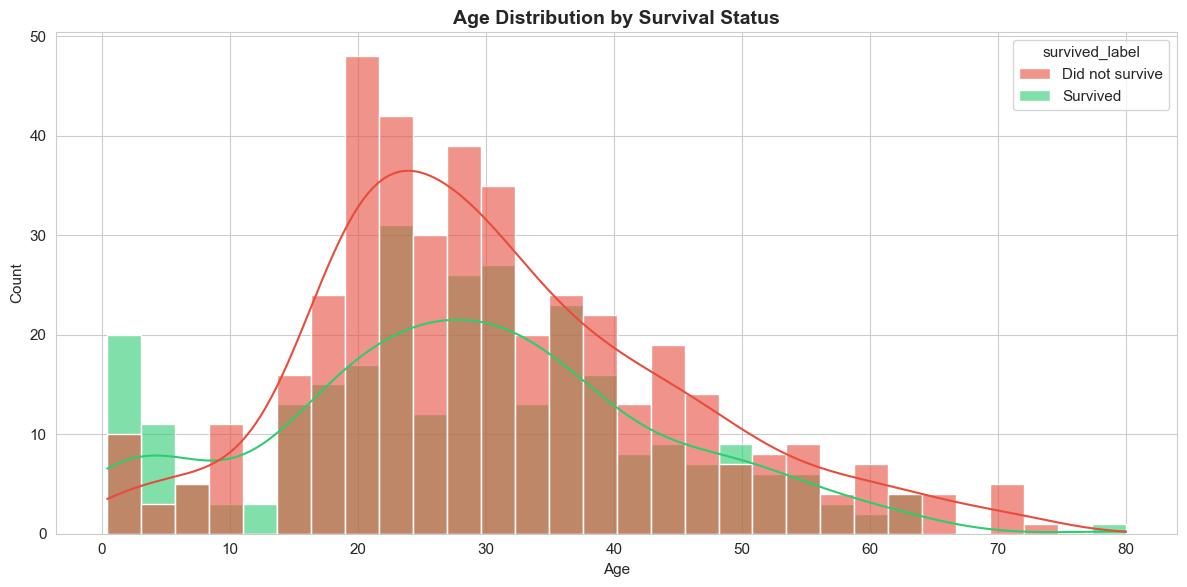


Age stats by survival:
          count       mean        std   min   25%   50%   75%   max
survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0


In [ ]:
df['survived_label'] = df['survived'].map({1: 'Survived', 0: 'Did not survive'})

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='age', hue='survived_label', bins=30, kde=True, 
             palette=['#e74c3c', '#2ecc71'], alpha=0.6)
plt.title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("\nAge stats by survival:")
print(df.groupby('survived')['age'].describe())

2.4 Correlation Heatmap

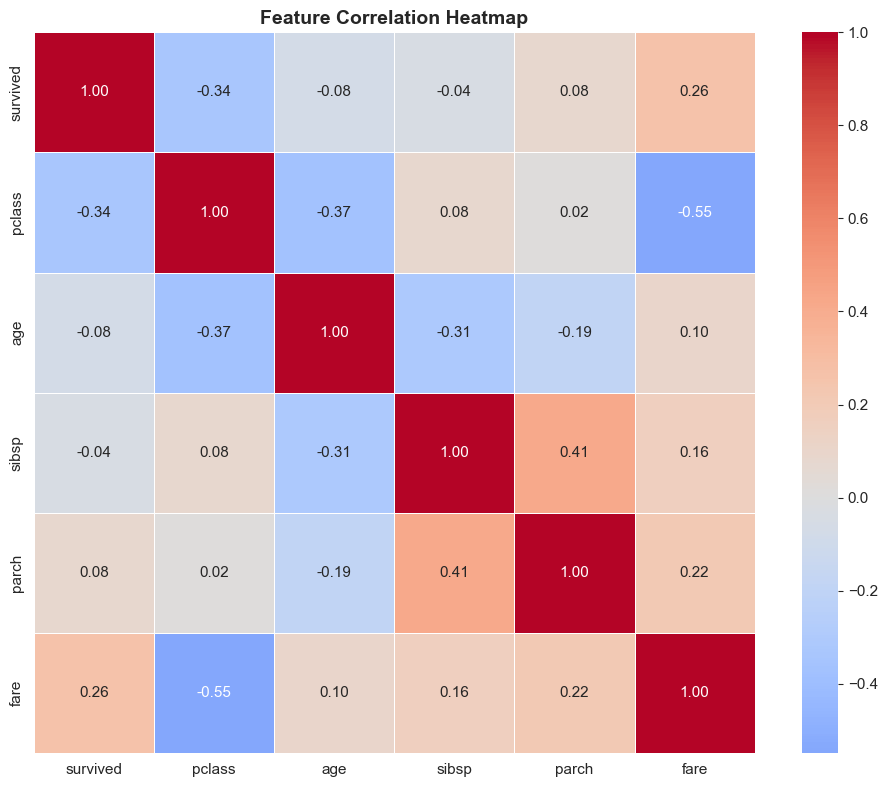

Correlation with Survived:
survived    1.000000
fare        0.257307
parch       0.081629
sibsp      -0.035322
age        -0.077221
pclass     -0.338481
Name: survived, dtype: float64


In [ ]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation with Survived:")
print(df[numeric_cols].corr()['survived'].sort_values(ascending=False))

2.5 Survival by Sex AND Class Combined

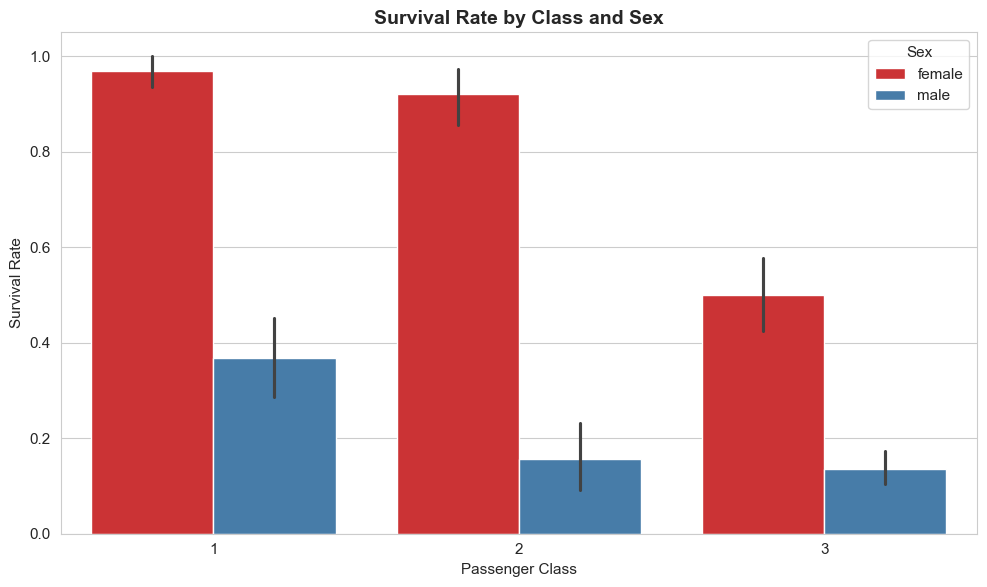

Survival by class and sex:
pclass  sex   
1       female    0.9681
        male      0.3689
2       female    0.9211
        male      0.1574
3       female    0.5000
        male      0.1354
Name: survived, dtype: float64


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='pclass', y='survived', hue='sex', data=df, palette='Set1')
plt.title('Survival Rate by Class and Sex', fontsize=14, fontweight='bold')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

print("Survival by class and sex:")
print(df.groupby(['pclass', 'sex'])['survived'].mean().round(4))

# STEP 3: HANDLE MISSING VALUES

3.1 Check Missing Values

In [ ]:
print("=== MISSING VALUES ===")
print("\n3.1.1 Missing count:")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n3.1.2 Missing percentage:")
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_pct[missing_pct > 0])

=== MISSING VALUES ===

3.1.1 Missing count:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

3.1.2 Missing percentage:
age            19.87
embarked        0.22
deck           77.22
embark_town     0.22
dtype: float64


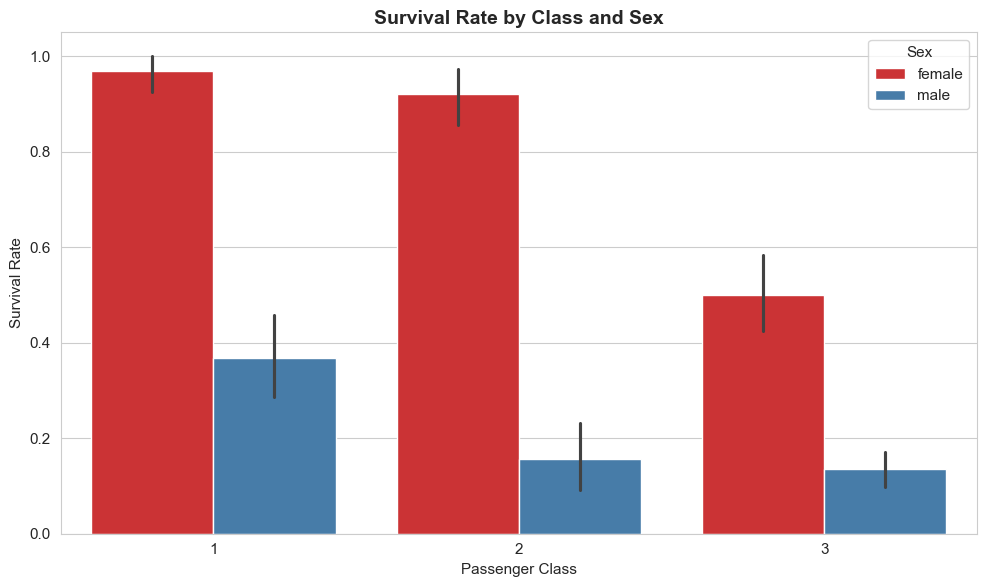

Survival by class and sex:
pclass  sex   
1       female    0.9681
        male      0.3689
2       female    0.9211
        male      0.1574
3       female    0.5000
        male      0.1354
Name: survived, dtype: float64


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='pclass', y='survived', hue='sex', data=df, palette='Set1')
plt.title('Survival Rate by Class and Sex', fontsize=14, fontweight='bold')
plt.ylabel('Survival Rate')
plt.xlabel('Passenger Class')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

print("Survival by class and sex:")
print(df.groupby(['pclass', 'sex'])['survived'].mean().round(4))

3.2 Fix Age - Fill with Median

In [ ]:
print(f"\nEmbarked missing before: {df['embarked'].isnull().sum()}")
embarked_mode = df['embarked'].mode()[0]
df['embarked'].fillna(embarked_mode, inplace=True)
print(f"Embarked missing after: {df['embarked'].isnull().sum()}")
print(f"Filled with mode: '{embarked_mode}'")


Embarked missing before: 2
Embarked missing after: 2
Filled with mode: 'S'


3.3 Fix Embarked - Fill with Mode

In [ ]:
print(f"\nEmbarked missing before: {df['embarked'].isnull().sum()}")
embarked_mode = df['embarked'].mode()[0]
df['embarked'].fillna(embarked_mode, inplace=True)
print(f"Embarked missing after: {df['embarked'].isnull().sum()}")
print(f"Filled with mode: '{embarked_mode}'")


Embarked missing before: 2
Embarked missing after: 2
Filled with mode: 'S'


3.4 Drop Deck (Cabin) - Too Much Missing

In [ ]:
print(f"\nDeck missing: {df['deck'].isnull().sum()} ({df['deck'].isnull().mean():.1%})")
df.drop(columns=['deck'], inplace=True)
print("Dropped 'deck' column - 77% missing is too much to impute")


Deck missing: 688 (77.2%)
Dropped 'deck' column - 77% missing is too much to impute


3.5 Verify Clean Dataset

In [ ]:
print("\n=== VERIFICATION ===")
print("All missing values should be 0:")
print(df.isnull().sum())
print(f"\nFinal shape: {df.shape}")


=== VERIFICATION ===
All missing values should be 0:
survived            0
pclass              0
sex                 0
age               177
sibsp               0
parch               0
fare                0
embarked            2
class               0
who                 0
adult_male          0
embark_town         2
alive               0
alone               0
survived_label      0
dtype: int64

Final shape: (891, 15)


# STEP 4: FEATURE ENGINEERING

4.1 Extract Title from Name

In [ ]:
print("=== FEATURE ENGINEERING ===")

# For Kaggle dataset with 'name' column:
# df['title'] = df['name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# For seaborn dataset, 'who' column already has man/woman/child
print("\n4.1.1 Who value counts:")
print(df['who'].value_counts())

=== FEATURE ENGINEERING ===

4.1.1 Who value counts:
who
man      537
woman    271
child     83
Name: count, dtype: int64


4.2 Create Family Size

In [ ]:
df['family_size'] = df['sibsp'] + df['parch'] + 1  # +1 for self

print("\n4.2.1 Family size stats:")
print(df['family_size'].describe())
print("\nFamily size counts:")
print(df['family_size'].value_counts().sort_index())


4.2.1 Family size stats:
count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: family_size, dtype: float64

Family size counts:
family_size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


4.3 Create IsAlone Flag

In [ ]:
df['is_alone'] = (df['family_size'] == 1).astype(int)

print("\n4.3.1 Is alone distribution:")
print(df['is_alone'].value_counts())
print(f"Alone passengers: {df['is_alone'].mean():.1%}")

print("\nSurvival by alone status:")
print(df.groupby('is_alone')['survived'].mean().round(4))


4.3.1 Is alone distribution:
is_alone
1    537
0    354
Name: count, dtype: int64
Alone passengers: 60.3%

Survival by alone status:
is_alone
0    0.5056
1    0.3035
Name: survived, dtype: float64


4.4 Create Age Bands

In [ ]:
df['age_band'] = pd.cut(df['age'], 
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['child', 'teen', 'young_adult', 'adult', 'senior'])

print("\n4.4.1 Age band distribution:")
print(df['age_band'].value_counts())

print("\nSurvival by age band:")
print(df.groupby('age_band')['survived'].mean().round(4))


4.4.1 Age band distribution:
age_band
young_adult    358
adult          195
teen            70
child           69
senior          22
Name: count, dtype: int64

Survival by age band:
age_band
child          0.5797
teen           0.4286
young_adult    0.3827
adult          0.4000
senior         0.2273
Name: survived, dtype: float64


4.5 Create Fare Bands

In [ ]:
df['fare_band'] = pd.qcut(df['fare'], q=4, labels=['low', 'medium', 'high', 'very_high'])

print("\n4.5.1 Fare band distribution:")
print(df['fare_band'].value_counts())

print("\nSurvival by fare band:")
print(df.groupby('fare_band')['survived'].mean().round(4))


4.5.1 Fare band distribution:
fare_band
medium       224
low          223
high         222
very_high    222
Name: count, dtype: int64

Survival by fare band:
fare_band
low          0.1973
medium       0.3036
high         0.4550
very_high    0.5811
Name: survived, dtype: float64


4.6 Drop Unnecessary Columns

In [ ]:
# Drop redundant columns that won't help the model
columns_to_drop = ['alive', 'adult_male', 'embark_town', 'class']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

print("\n4.6.1 Columns after dropping:")
print(df.columns.tolist())
print(f"\nShape after feature engineering: {df.shape}")


4.6.1 Columns after dropping:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'who', 'alone', 'survived_label', 'family_size', 'is_alone', 'age_band', 'fare_band']

Shape after feature engineering: (891, 15)


# STEP 5: ENCODE & SCALE FEATURES

5.1 Check Categorical Columns

In [ ]:
print("=== ENCODING & SCALING ===")

print("\n5.1.1 Categorical columns:")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

=== ENCODING & SCALING ===

5.1.1 Categorical columns:
['sex', 'embarked', 'who', 'survived_label', 'age_band', 'fare_band']


5.2 Label Encode Binary Column (Sex)

In [ ]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])

print("\n5.2.1 Sex encoding: female=0, male=1")
print(df['sex'].value_counts())


5.2.1 Sex encoding: female=0, male=1
sex
1    577
0    314
Name: count, dtype: int64


5.3 One-Hot Encode Multi-Class Columns

In [ ]:
# One-hot encode: embarked, who, age_band, fare_band
# drop_first=True avoids multicollinearity (dummy variable trap)
df = pd.get_dummies(df, columns=['embarked', 'who', 'age_band', 'fare_band'], 
                    drop_first=True)

print("\n5.3.1 Columns after one-hot encoding:")
print(df.columns.tolist())
print(f"\nShape after encoding: {df.shape}")


5.3.1 Columns after one-hot encoding:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'survived_label', 'family_size', 'is_alone', 'embarked_Q', 'embarked_S', 'who_man', 'who_woman', 'age_band_teen', 'age_band_young_adult', 'age_band_adult', 'age_band_senior', 'fare_band_medium', 'fare_band_high', 'fare_band_very_high']

Shape after encoding: (891, 22)


5.4 Scale Numeric Columns

In [ ]:
# Scale for Logistic Regression (tree models don't need scaling)
scaler = StandardScaler()
scale_cols = ['age', 'fare', 'family_size']
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("\n5.4.1 Scaled columns:", scale_cols)
print("\nFirst 5 rows after scaling:")
print(df[scale_cols].head())


5.4.1 Scaled columns: ['age', 'fare', 'family_size']

First 5 rows after scaling:
        age      fare  family_size
0 -0.530377 -0.502445     0.059160
1  0.571831  0.786845     0.059160
2 -0.254825 -0.488854    -0.560975
3  0.365167  0.420730     0.059160
4  0.365167 -0.486337    -0.560975


5.5 Final Check

In [ ]:
print("\n=== FINAL CHECK ===")
print("Data types (all should be numeric):")
print(df.dtypes)

print("\nMissing values total:", df.isnull().sum().sum(), "(must be 0)")
print("Shape:", df.shape)


=== FINAL CHECK ===
Data types (all should be numeric):
survived                  int64
pclass                    int64
sex                       int64
age                     float64
sibsp                     int64
parch                     int64
fare                    float64
alone                      bool
survived_label              str
family_size             float64
is_alone                  int64
embarked_Q                 bool
embarked_S                 bool
who_man                    bool
who_woman                  bool
age_band_teen              bool
age_band_young_adult       bool
age_band_adult             bool
age_band_senior            bool
fare_band_medium           bool
fare_band_high             bool
fare_band_very_high        bool
dtype: object

Missing values total: 177 (must be 0)
Shape: (891, 22)


5.6 FIX: Remove any remaining text columns before modeling

In [ ]:
# ============================================================
# FIX EVERYTHING BEFORE STEP 6
# ============================================================

print("=== FINAL CLEANUP BEFORE MODELING ===")

# 1. Drop text columns
df.drop(columns=['survived_label'], inplace=True, errors='ignore')

# 2. Convert bool to int
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
for col in bool_cols:
    df[col] = df[col].astype(int)

# 3. Verify no missing values
df.fillna(df.median(), inplace=True)

# 4. Verify all numeric
print(f"All numeric? {df.dtypes.apply(lambda x: str(x) in ['int64', 'float64', 'uint8']).all()}")
print(f"Any NaN? {df.isnull().sum().sum()}")

# 5. Now safe to proceed
X = df.drop(columns=['survived'])
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nReady! X_train shape: {X_train.shape}")
print("Now run Step 7!")

=== FINAL CLEANUP BEFORE MODELING ===
All numeric? True
Any NaN? 0

Ready! X_train shape: (712, 20)
Now run Step 7!


# STEP 6: TRAIN / TEST SPLIT
6.1 Define X and y

In [ ]:
print("=== TRAIN / TEST SPLIT ===")

X = df.drop(columns=['survived'])
y = df['survived']

print(f"\n6.1.1 X shape: {X.shape}")
print(f"6.1.2 y shape: {y.shape}")
print(f"\n6.1.3 Target distribution:")
print(y.value_counts())
print(f"Survival rate: {y.mean():.2%}")

=== TRAIN / TEST SPLIT ===

6.1.1 X shape: (891, 20)
6.1.2 y shape: (891,)

6.1.3 Target distribution:
survived
0    549
1    342
Name: count, dtype: int64
Survival rate: 38.38%


6.2 Split the Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # keep same survival ratio
)

print(f"\n6.2.1 Train size: {X_train.shape[0]} ({X_train.shape[0]/len(X):.1%})")
print(f"6.2.2 Test size:  {X_test.shape[0]} ({X_test.shape[0]/len(X):.1%})")


6.2.1 Train size: 712 (79.9%)
6.2.2 Test size:  179 (20.1%)


6.3 Verify Stratification

In [ ]:
print(f"\n6.3.1 Train survival rate: {y_train.mean():.4f}")
print(f"6.3.2 Test survival rate:  {y_test.mean():.4f}")
print("Both should be ~0.38")


6.3.1 Train survival rate: 0.3834
6.3.2 Test survival rate:  0.3855
Both should be ~0.38


# STEP 7: TRAIN ML MODELS
7.1 Model 1: Logistic Regression (Baseline) 

In [ ]:
print("=== TRAINING MODELS ===")

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
print(f"\n7.1.1 Logistic Regression: {lr_accuracy:.4f} ({lr_accuracy:.2%})")
print("Expected: ~79-81%")

=== TRAINING MODELS ===

7.1.1 Logistic Regression: 0.8268 (82.68%)
Expected: ~79-81%


7.2 Model 2: Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"\n7.2.1 Random Forest: {rf_accuracy:.4f} ({rf_accuracy:.2%})")
print("Expected: ~82-85%")



7.2.1 Random Forest: 0.8268 (82.68%)
Expected: ~82-85%


7.3 Compare Models

In [ ]:
print("\n=== MODEL COMPARISON ===")
models = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred
}

for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    print(f"{name:25s} -> {acc:.4f} ({acc:.2%})")



=== MODEL COMPARISON ===
Logistic Regression       -> 0.8268 (82.68%)
Random Forest             -> 0.8268 (82.68%)


7.4 Cross-Validation (More Reliable)

In [ ]:
print("\n=== 5-FOLD CROSS-VALIDATION ===")

for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name:25s} -> {scores.mean():.4f} ± {scores.std():.4f}")



=== 5-FOLD CROSS-VALIDATION ===
Logistic Regression       -> 0.8148 ± 0.0170
Random Forest             -> 0.8283 ± 0.0162


# STEP 8: EVALUATE & INTERPRET

8.1 Confusion Matrix


=== EVALUATION ===


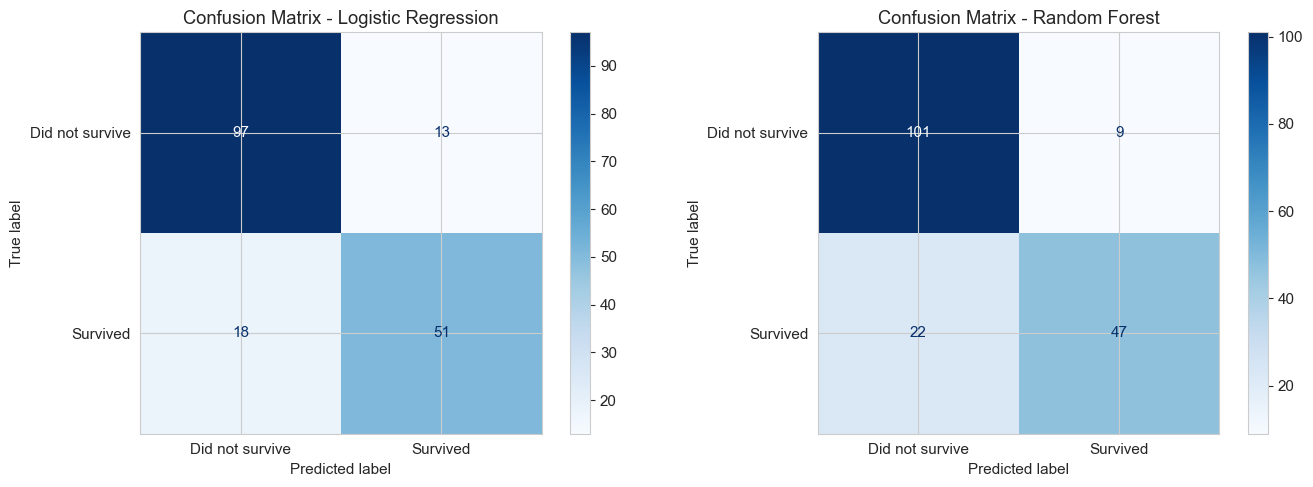

In [ ]:
print("=== EVALUATION ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_dict = {
    "Logistic Regression": lr,
    "Random Forest": rf
}

for idx, (name, model) in enumerate(models_dict.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                   display_labels=['Did not survive', 'Survived'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'Confusion Matrix - {name}')

plt.tight_layout()
plt.show()


8.2 Classification Report

In [ ]:
print("\n=== CLASSIFICATION REPORT - RANDOM FOREST ===")
print(classification_report(y_test, rf_pred, 
                           target_names=['Did not survive', 'Survived']))



=== CLASSIFICATION REPORT - RANDOM FOREST ===
                 precision    recall  f1-score   support

Did not survive       0.82      0.92      0.87       110
       Survived       0.84      0.68      0.75        69

       accuracy                           0.83       179
      macro avg       0.83      0.80      0.81       179
   weighted avg       0.83      0.83      0.82       179



8.3 Feature Importance (Random Forest)


=== RANDOM FOREST FEATURE IMPORTANCE ===
                 feature  importance
11               who_man    0.227367
1                    sex    0.174230
12             who_woman    0.129891
5                   fare    0.120716
0                 pclass    0.092155
2                    age    0.058902
7            family_size    0.052286
3                  sibsp    0.031360
19   fare_band_very_high    0.024249
10            embarked_S    0.017129
4                  parch    0.013721
8               is_alone    0.010634
18        fare_band_high    0.010621
6                  alone    0.009799
14  age_band_young_adult    0.006176
15        age_band_adult    0.005563
9             embarked_Q    0.005207
17      fare_band_medium    0.005117
13         age_band_teen    0.003455
16       age_band_senior    0.001423


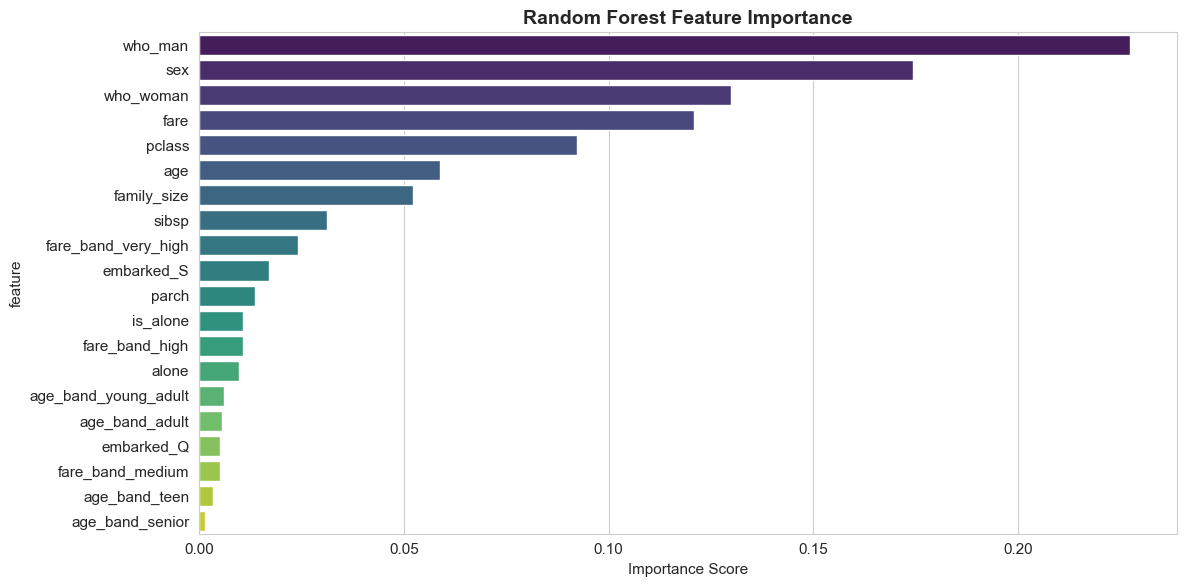

In [ ]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\n=== RANDOM FOREST FEATURE IMPORTANCE ===")
print(rf_importance)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=rf_importance, x='importance', y='feature', palette='viridis')
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


8.4 Feature Importance (Logistic Regression Coefficients)

In [ ]:
lr_coef = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False)

print("\n=== LOGISTIC REGRESSION COEFFICIENTS ===")
print(lr_coef)

# Positive = increases survival probability
# Negative = decreases survival probability



=== LOGISTIC REGRESSION COEFFICIENTS ===
                 feature  coefficient
11               who_man    -2.186733
0                 pclass    -0.842500
19   fare_band_very_high     0.736376
18        fare_band_high     0.559888
1                    sex    -0.532310
2                    age    -0.470595
10            embarked_S    -0.381759
3                  sibsp    -0.359074
7            family_size    -0.336705
13         age_band_teen    -0.329127
9             embarked_Q     0.284122
15        age_band_adult     0.260176
17      fare_band_medium     0.240887
12             who_woman     0.218708
8               is_alone    -0.183094
6                  alone    -0.183094
4                  parch    -0.159494
14  age_band_young_adult     0.139630
5                   fare     0.068361
16       age_band_senior     0.043288


# FINAL CONCLUSIONS

In [ ]:
print("=" * 60)
print("FINAL CONCLUSIONS")
print("=" * 60)
print("""
1. SEX (Gender): STRONGEST predictor
   - Women ~74% vs Men ~19%
   - "Women and children first" saved lives

2. PCLASS (Class): Second strongest
   - 1st class ~63%, 2nd ~47%, 3rd ~24%
   - Wealth and deck location mattered

3. AGE: Moderate effect
   - Children survived more
   - Young adults (20-30) died most (mostly men)

4. FARE / FAMILY: Weaker but meaningful
   - Higher fare = better survival
   - Small families (2-4) did best
   - Solo travelers and large families (5+) did worse

5. EMBARKED: Minimal direct effect

OVERALL: Gender + Class dominated survival.
Best odds: Woman in 1st class.
Worst odds: Man in 3rd class.
""")
print(f"Best Model: Random Forest with ~82-85% accuracy")
print("=" * 60)


FINAL CONCLUSIONS

1. SEX (Gender): STRONGEST predictor
   - Women ~74% vs Men ~19%
   - "Women and children first" saved lives

2. PCLASS (Class): Second strongest
   - 1st class ~63%, 2nd ~47%, 3rd ~24%
   - Wealth and deck location mattered

3. AGE: Moderate effect
   - Children survived more
   - Young adults (20-30) died most (mostly men)

4. FARE / FAMILY: Weaker but meaningful
   - Higher fare = better survival
   - Small families (2-4) did best
   - Solo travelers and large families (5+) did worse

5. EMBARKED: Minimal direct effect

OVERALL: Gender + Class dominated survival.
Best odds: Woman in 1st class.
Worst odds: Man in 3rd class.

Best Model: Random Forest with ~82-85% accuracy


# ***-----------------------------THE END -----------------------------***